# LLM-based Mistake Identification Analysis

This notebook implements a comprehensive pipeline for:
1. Loading the dataset from JSON files
2. Solving math problems using Mathstral LLM to generate answer keys
3. Evaluating mistake identification using Llama 3.1 70B
4. Analyzing results with confusion matrices and performance metrics

## Step 1: Import Required Libraries and Setup

In [1]:
import json
import os
import re
from typing import Dict, List, Any
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# For LLM API calls
import requests
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

# Set up plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Libraries imported successfully!
PyTorch version: 2.8.0+cu129
CUDA available: True


## Step 2: Load Dataset from JSON Files

In [18]:
# Define paths
DATA_DIR = "/DATA/cs24resch11011/repos/pedagogical-assessment/data"
TRAINSET_PATH = os.path.join(DATA_DIR, "trainset.json")
DEVSET_PATH = os.path.join(DATA_DIR, "dev_testset.json")
TESTSET_PATH = os.path.join(DATA_DIR, "testset.json")

# Load trainset
with open(TRAINSET_PATH, 'r') as f:
    trainset = json.load(f)

print(f"Loaded {len(trainset)} conversations from trainset.json")
print(f"\nFirst conversation structure:")
print(f"- conversation_id: {trainset[0]['conversation_id']}")
print(f"- conversation_history: {trainset[0]['conversation_history']}...")
print(f"- Number of tutor responses: {len(trainset[0]['tutor_responses'])}")
print(f"- Response sources: {list(trainset[0]['tutor_responses'].keys())}")

Loaded 300 conversations from trainset.json

First conversation structure:
- conversation_id: 221-362eb11a-f190-42a6-b2a4-985fafdcfa9e
- conversation_history: Tutor: Hi, could you please provide a step-by-step solution for the question below? The question is: Tyson decided to make muffaletta sandwiches for the big game.  Each sandwich required 1 pound each of meat and cheese and would serve 4 people.  There would be 20 people in total watching the game.  The meat cost $7.00 per pound and the cheese cost $3.00 per pound.  How much money would he spend on the meat and cheese to make enough sandwiches to serve 20 people? 
 Student: To serve 20 people, Tyson needs to make 20/4 = 5 sandwiches.
Each sandwich requires 1+1 = 2 pounds of meat and cheese.
For 5 sandwiches, he needs a total of 2 x 5 = 10 pounds of meat and cheese.
The cost of 10 pounds of meat is 10 x $7.00 = $70.
The cost of 10 pounds of cheese is 10 x $3.00 = $30.
The total cost of meat and cheese is $70 + $30 = $100.
 100 
 Tu

## Step 3: Extract Math Questions from Conversations

In [25]:
def extract_question_from_conversation(conversation_history: str) -> str:
    """
    Extract the math question from the conversation history.
    The question usually appears after "The question is:" in the first tutor message.
    """
    # Look for pattern "The question is:" or "question below?"
    patterns = [
        r"The question is:\s*(.+?)\s*\n\s*Student:",
        r"question below\?\s*(.+?)\s*\n\s*Student:",
        r"Tutor:\s*(.+?)\s*\n\s*Student:"
    ]
    
    for pattern in patterns:
        match = re.search(pattern, conversation_history, re.DOTALL)
        if match:
            question = match.group(1).strip()
            # Clean up the question
            question = question.replace("\\n", " ").strip()
            if len(question) > 20:  # Valid question should be reasonably long
                return question
    
    # Fallback: extract first tutor message
    lines = conversation_history.split("\n")
    for line in lines:
        if line.strip().startswith("Tutor:"):
            return line.replace("Tutor:", "").strip()
    
    return conversation_history[:500]  # Last resort

# Test extraction on first few conversations
print("Extracting questions from conversations...\n")
for i in range(min(5, len(trainset))):
    conversation_id = trainset[i]['conversation_id']
    question = extract_question_from_conversation(trainset[i]['conversation_history'])
    print(f"Conversation Id: {conversation_id}")
    print(f"Conversation {i+1}:")
    print(f"Question: {question}")
    print()

Extracting questions from conversations...

Conversation Id: 221-362eb11a-f190-42a6-b2a4-985fafdcfa9e
Conversation 1:
Question: Tyson decided to make muffaletta sandwiches for the big game.  Each sandwich required 1 pound each of meat and cheese and would serve 4 people.  There would be 20 people in total watching the game.  The meat cost $7.00 per pound and the cheese cost $3.00 per pound.  How much money would he spend on the meat and cheese to make enough sandwiches to serve 20 people?

Conversation Id: 4642-e2ccfa55-280b-421c-9245-25ff56e3f33e
Conversation 2:
Question: In a rice field, you can get a total of 20 sacks of rice every harvest. If the yield increases by twenty percent after every harvest, what is the total number of sacks of rice you can get after the first and second harvest?

Conversation Id: 258053434
Conversation 3:
Question: You earn one point for your good beginning. 
 Tutor: That was a good try. 
 Tutor: What is the value of 3^3?

Conversation Id: 429563766
Conve

## Step 4: Setup Mathstral LLM for Answer Generation

We'll use Mistral AI's Mathstral model (mathstral-7B-v0.1) for solving math problems.

In [ ]:
class MathSolver:
    """
    Math problem solver using Mathstral or similar math-focused LLM.
    Supports both local model loading and API-based inference.
    """
    
    def __init__(self, model_name="mistralai/Mathstral-7B-v0.1", use_local=True):
        self.model_name = model_name
        self.use_local = use_local
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        
        if use_local:
            print(f"Loading {model_name} model...")
            print(f"Using device: {self.device}")
            try:
                self.tokenizer = AutoTokenizer.from_pretrained(model_name)
                self.model = AutoModelForCausalLM.from_pretrained(
                    model_name,
                    dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
                    device_map="auto" if torch.cuda.is_available() else None,
                    low_cpu_mem_usage=True
                )
                print("Model loaded successfully!")
            except Exception as e:
                print(f"Error loading model: {e}")
                print("Falling back to API mode or alternative approach")
                self.use_local = False
    
    def solve_math_problem(self, question: str, max_length=1024) -> str:
        """
        Solve a math problem and return the step-by-step solution with final answer.
        """
        prompt = f"""Solve the following math problem step by step. Provide a clear, detailed solution and state the final answer clearly at the end.

Question: {question}

Solution:"""
        
        if self.use_local and hasattr(self, 'model'):
            try:
                inputs = self.tokenizer(prompt, return_tensors="pt").to(self.device)
                
                with torch.no_grad():
                    outputs = self.model.generate(
                        **inputs,
                        max_new_tokens=max_length,
                        temperature=0.1,  # Low temperature for more deterministic math answers
                        do_sample=True,
                        top_p=0.9,
                        pad_token_id=self.tokenizer.eos_token_id
                    )
                
                solution = self.tokenizer.decode(outputs[0], skip_special_tokens=True)
                # Extract only the solution part (after the prompt)
                solution = solution.split("Solution:")[-1].strip()
                return solution
            except Exception as e:
                print(f"Error during inference: {e}")
                return self._fallback_solution(question)
        else:
            return self._fallback_solution(question)
    
    def _fallback_solution(self, question: str) -> str:
        """
        Fallback method when model is not available.
        Returns a placeholder that indicates manual solution is needed.
        """
        return f"[Solution requires computation for: {question}...]"

# Initialize the math solver
print("Initializing Math Solver...")
math_solver = MathSolver(model_name="mistralai/Mathstral-7B-v0.1", use_local=True)
print("Math Solver ready!")

Initializing Math Solver...
Loading mistralai/Mathstral-7B-v0.1 model...
Using device: cuda


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/588k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

...

model-00001-of-00006.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00006-of-00006.safetensors:   0%|          | 0.00/4.26G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

Model loaded successfully!
Math Solver ready!


## Step 5: Generate Answers for All Questions

Generate answer keys for all conversations in the trainset.

In [ ]:
from tqdm import tqdm

def generate_answers_for_dataset(dataset, math_solver, max_samples=None):
    """
    Generate answer keys for all conversations in the dataset.
    
    Args:
        dataset: List of conversation dictionaries
        math_solver: MathSolver instance
        max_samples: Maximum number of samples to process (None for all)
    
    Returns:
        Updated dataset with 'answer_key' field added
    """
    dataset_with_answers = []
    
    num_samples = len(dataset) if max_samples is None else min(max_samples, len(dataset))
    
    print(f"Generating answers for {num_samples} conversations...")
    
    for i, conversation in enumerate(tqdm(dataset[:num_samples], desc="Solving problems")):
        # Create a copy of the conversation
        conv_with_answer = conversation.copy()
        
        # Extract question
        question = extract_question_from_conversation(conversation['conversation_history'])
        
        # Generate answer
        try:
            answer = math_solver.solve_math_problem(question)
            conv_with_answer['answer_key'] = answer
        except Exception as e:
            print(f"\nError solving question {i+1}: {e}")
            conv_with_answer['answer_key'] = f"[Error generating answer: {str(e)}]"
        
        dataset_with_answers.append(conv_with_answer)
        
        # Show progress for first few
        if i < 3:
            print(f"\n{'='*80}")
            print(f"Conversation {i+1}:")
            print(f"Question: {question}...")
            print(f"Answer: {conv_with_answer['answer_key']}...")
    
    return dataset_with_answers

# Generate answers for a subset first (for testing)
# Set to None to process all conversations
NUM_SAMPLES_TO_PROCESS = 5  # Start with 5 for testing, change to None for full dataset

trainset_with_answers = generate_answers_for_dataset(
    trainset, 
    math_solver, 
    max_samples=NUM_SAMPLES_TO_PROCESS
)

print(f"\n{'='*80}")
print(f"Successfully generated answers for {len(trainset_with_answers)} conversations!")

Generating answers for 10 conversations...


Solving problems:  10%|█         | 1/10 [00:09<01:21,  9.05s/it]


Conversation 1:
Question: Tyson decided to make muffaletta sandwiches for the big game.  Each sandwich required 1 pound each of meat and cheese and would serve 4 people.  There would be 20 people in total watching the game.  The meat cost $7.00 per pound and the cheese cost $3.00 per pound.  How much money would he spend on the meat and cheese to make enough sandwiches to serve 20 people?...
Answer: 1. First, we need to determine how many sandwiches Tyson needs to make to serve 20 people. Since each sandwich serves 4 people, we divide the total number of people by the number of people each sandwich serves:

Number of sandwiches = Total number of people / People served per sandwich
= 20 / 4
= 5 sandwiches

2. Next, we need to calculate the total amount of meat and cheese needed for these sandwiches. Each sandwich requires 1 pound of meat and 1 pound of cheese, so for 5 sandwiches, Tyson will need:

Meat = Number of sandwiches * Meat per sandwich
= 5 * 1
= 5 pounds

Cheese = Number of s

Solving problems:  20%|██        | 2/10 [00:13<00:51,  6.44s/it]


Conversation 2:
Question: In a rice field, you can get a total of 20 sacks of rice every harvest. If the yield increases by twenty percent after every harvest, what is the total number of sacks of rice you can get after the first and second harvest?...
Answer: 1. First, we need to find out how many sacks of rice are produced in the second harvest. Since the yield increases by twenty percent after every harvest, we can calculate the number of sacks produced in the second harvest by multiplying the number of sacks produced in the first harvest by 1.2 (which represents a 20% increase).

Number of sacks in the second harvest = Number of sacks in the first harvest * 1.2
= 20 * 1.2
= 24

2. Now, we can find the total number of sacks of rice produced after the first and second harvest by adding the number of sacks produced in the first harvest to the number of sacks produced in the second harvest.

Total number of sacks = Number of sacks in the first harvest + Number of sacks in the second h

Solving problems:  30%|███       | 3/10 [00:15<00:29,  4.23s/it]


Conversation 3:
Question: You earn one point for your good beginning. 
 Tutor: That was a good try. 
 Tutor: What is the value of 3^3?...
Answer: 1. The problem asks for the value of 3^3.
2. The expression 3^3 means 3 multiplied by itself 3 times.
3. So, we calculate 3 * 3 * 3.
4. The result is 27.

Final answer: \boxed{27}...


Solving problems: 100%|██████████| 10/10 [00:37<00:00,  3.78s/it]


Successfully generated answers for 10 conversations!


## Step 6: Save Updated Dataset with Answer Keys

In [28]:
# Save the updated dataset
OUTPUT_DIR = "/DATA/cs24resch11011/repos/pedagogical-assessment/devendra/mistake_identification/llm_approach"
os.makedirs(OUTPUT_DIR, exist_ok=True)

OUTPUT_FILE = os.path.join(OUTPUT_DIR, "trainset_with_answers.json")

with open(OUTPUT_FILE, 'w') as f:
    json.dump(trainset_with_answers, f, indent=2)

print(f"Saved updated dataset to: {OUTPUT_FILE}")
print(f"Total conversations: {len(trainset_with_answers)}")
print(f"\nSample conversation structure:")
print(json.dumps(trainset_with_answers[0], indent=2))

Saved updated dataset to: /DATA/cs24resch11011/repos/pedagogical-assessment/devendra/mistake_identification/llm_approach/trainset_with_answers.json
Total conversations: 10

Sample conversation structure:
{
  "conversation_id": "221-362eb11a-f190-42a6-b2a4-985fafdcfa9e",
  "conversation_history": "Tutor: Hi, could you please provide a step-by-step solution for the question below? The question is: Tyson decided to make muffaletta sandwiches for the big game.\u00a0\u00a0Each sandwich required 1 pound each of meat and cheese and would serve 4 people.\u00a0\u00a0There would be 20 people in total watching the game.\u00a0\u00a0The meat cost $7.00 per pound and the cheese cost $3.00 per pound.\u00a0\u00a0How much money would he spend on the meat and cheese to make enough sandwiches to serve 20 people?\u00a0\n\u00a0Student: To serve 20 people, Tyson needs to make 20/4 = 5 sandwiches.\nEach sandwich requires 1+1 = 2 pounds of meat and cheese.\nFor 5 sandwiches, he needs a total of 2 x 5 = 10 pou

## Step 7: Setup Llama 3.1 70B for Mistake Identification Evaluation

We'll use Llama 3.1 70B (or 8B if 70B is not available) to evaluate whether the tutor responses correctly identified the student's mistake.

In [54]:
class MistakeIdentificationEvaluator:
    """
    Evaluator using Llama 3.1 70B (or 8B) to assess whether tutor responses
    correctly identified student mistakes.
    """
    
    def __init__(self, model_name="mistralai/Mathstral-7B-v0.1", use_local=True):
        """
        Initialize the evaluator.
        Using 8B version as it's more accessible. Can change to 70B if available:
        "meta-llama/Llama-3.1-70B-Instruct"
        """
        self.model_name = model_name
        self.use_local = use_local
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        
        if use_local:
            print(f"Loading {model_name} model...")
            print(f"Using device: {self.device}")
            try:
                self.tokenizer = AutoTokenizer.from_pretrained(model_name)
                self.model = AutoModelForCausalLM.from_pretrained(
                    model_name,
                    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
                    device_map="auto" if torch.cuda.is_available() else None,
                    low_cpu_mem_usage=True
                )
                print("Model loaded successfully!")
            except Exception as e:
                print(f"Error loading model: {e}")
                print("Will use rule-based fallback")
                self.use_local = False
    
    def evaluate_mistake_identification(
        self, 
        conversation_history: str, 
        correct_answer: str, 
        tutor_response: str
    ) -> str:
        """
        Evaluate whether the tutor response correctly identified the student's mistake.
        
        Returns: "Yes", "No", or "To some extent"
        """
        prompt = f"""You are an expert educational assessment evaluator in mathematics subject. Your task is to evaluate whether a tutor correctly identified a student's mistake in their response.

You will be given:
1. The conversation history between tutor and student
2. The correct answer to the problem
3. The tutor's response to the student

Based on this information, determine if the tutor successfully identified the student's mistake. Respond with EXACTLY ONE of these three options:
- "Yes" - if the tutor clearly and correctly identified the student's mistake. Even he is not fully correct, but he identified the mistake correctly. 40% correctness is enough.
- "No" - if the tutor failed to identify the mistake or identified the wrong issue
- "To some extent" - if the tutor partially identified the mistake but missed key aspects or was unclear

CONVERSATION HISTORY:
{conversation_history}

CORRECT ANSWER:
{correct_answer}

TUTOR'S RESPONSE:
{tutor_response}

EVALUATION (respond with ONLY "Yes", "No", or "To some extent"):"""

        if self.use_local and hasattr(self, 'model'):
            try:
                inputs = self.tokenizer(prompt, return_tensors="pt", truncation=True, max_length=4096).to(self.device)
                
                with torch.no_grad():
                    outputs = self.model.generate(
                        **inputs,
                        max_new_tokens=50,
                        temperature=0.5,
                        do_sample=True,
                        top_p=0.9,
                        pad_token_id=self.tokenizer.eos_token_id
                    )
                
                response = self.tokenizer.decode(outputs[0], skip_special_tokens=True)
                # Extract only the evaluation part
                response = response.split("EVALUATION")[-1].strip()
                
                # Parse the response to get clean category
                return self._parse_evaluation(response)
            except Exception as e:
                print(f"Error during evaluation: {e}")
                return self._fallback_evaluation(conversation_history, tutor_response)
        else:
            return self._fallback_evaluation(conversation_history, tutor_response)
    
    def _parse_evaluation(self, response: str) -> str:
        """
        Parse the model's response to extract the evaluation category.
        """
        response_lower = response.lower()
        
        # Check for each category
        if "to some extent" in response_lower:
            return "To some extent"
        elif any(word in response_lower for word in ["yes", "correct", "successfully"]):
            # Make sure it's not "no" or negative
            if not any(word in response_lower for word in ["no", "not", "fail", "incorrect"]):
                return "Yes"
        
        # Check for "No"
        if any(word in response_lower[:50] for word in ["no", "not", "fail", "incorrect", "did not"]):
            return "No"
        
        # Default to "To some extent" if unclear
        return "To some extent"
    
    def _fallback_evaluation(self, conversation_history: str, tutor_response: str) -> str:
        """
        Simple rule-based fallback when model is not available.
        """
        response_lower = tutor_response.lower()
        
        # Keywords indicating mistake identification
        mistake_keywords = [
            "mistake", "error", "incorrect", "wrong", "not quite",
            "let's reconsider", "actually", "remember", "should be"
        ]
        
        guidance_keywords = [
            "try", "can you", "what if", "let's", "consider",
            "think about", "recall", "remember that"
        ]
        
        mistake_count = sum(1 for keyword in mistake_keywords if keyword in response_lower)
        guidance_count = sum(1 for keyword in guidance_keywords if keyword in response_lower)
        
        if mistake_count >= 2:
            return "Yes"
        elif mistake_count >= 1 or guidance_count >= 2:
            return "To some extent"
        else:
            return "No"

# Initialize the evaluator
print("Initializing Mistake Identification Evaluator...")
evaluator = MistakeIdentificationEvaluator(
    model_name="meta-llama/Llama-3.1-8B-Instruct",  # Change to 70B if available
    use_local=True
)
print("Evaluator ready!")

Initializing Mistake Identification Evaluator...
Loading meta-llama/Llama-3.1-8B-Instruct model...
Using device: cuda


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Model loaded successfully!
Evaluator ready!


## Step 8: Evaluate Mistake Identification for All Tutor Responses

Evaluate each tutor response (from different LLMs and experts) to determine if they correctly identified the student's mistake.

In [ ]:
def evaluate_all_responses(dataset_with_answers, evaluator):
    """
    Evaluate mistake identification for all tutor responses in the dataset.
    Adds 'llm_predicted_mistake_identification' to each response's annotation.
    """
    evaluated_dataset = []
    
    print(f"Evaluating mistake identification for all conversations...")
    
    for conv_idx, conversation in enumerate(tqdm(dataset_with_answers, desc="Evaluating")):
        evaluated_conv = conversation.copy()
        
        # Get conversation details
        conversation_history = conversation['conversation_history']
        answer_key = conversation.get('answer_key', 'Not available')
        
        # Evaluate each tutor response
        for source_name, response_data in conversation['tutor_responses'].items():
            tutor_response = response_data['response']
            
            # Perform evaluation
            try:
                predicted_category = evaluator.evaluate_mistake_identification(
                    conversation_history,
                    answer_key,
                    tutor_response
                )
                
                # Add prediction to annotation
                if 'annotation' not in evaluated_conv['tutor_responses'][source_name]:
                    evaluated_conv['tutor_responses'][source_name]['annotation'] = {}
                
                evaluated_conv['tutor_responses'][source_name]['annotation']['LLM_Predicted_Mistake_Identification'] = predicted_category
                
            except Exception as e:
                print(f"\nError evaluating conversation {conv_idx+1}, source {source_name}: {e}")
                evaluated_conv['tutor_responses'][source_name]['annotation']['LLM_Predicted_Mistake_Identification'] = "Error"
        
        evaluated_dataset.append(evaluated_conv)
        
        # Show first few examples
        if conv_idx < 2:
            print(f"\n{'='*80}")
            print(f"Conversation {conv_idx+1}:")
            for source_name, response_data in evaluated_conv['tutor_responses'].items():
                actual = response_data['annotation'].get('Mistake_Identification', 'N/A')
                predicted = response_data['annotation'].get('LLM_Predicted_Mistake_Identification', 'N/A')
                print(f"  {source_name}:")
                print(f"    Actual: {actual}")
                print(f"    Predicted: {predicted}")
    
    return evaluated_dataset

# Perform evaluation
trainset_evaluated = evaluate_all_responses(trainset_with_answers, evaluator)

print(f"\n{'='*80}")
print(f"Evaluation complete for {len(trainset_evaluated)} conversations!")

Evaluating mistake identification for all conversations...


Evaluating:  10%|█         | 1/10 [00:09<01:26,  9.57s/it]


Conversation 1:
  Sonnet:
    Actual: Yes
    Predicted: To some extent
  Llama318B:
    Actual: Yes
    Predicted: To some extent
  Llama31405B:
    Actual: Yes
    Predicted: To some extent
  GPT4:
    Actual: Yes
    Predicted: To some extent
  Mistral:
    Actual: Yes
    Predicted: To some extent
  Expert:
    Actual: Yes
    Predicted: To some extent
  Gemini:
    Actual: Yes
    Predicted: To some extent
  Phi3:
    Actual: No
    Predicted: To some extent


## Step 9: Save Final Dataset with Evaluations

In [42]:
# Save the final evaluated dataset
FINAL_OUTPUT_FILE = os.path.join(OUTPUT_DIR, "trainset_with_answers_and_evaluations.json")

with open(FINAL_OUTPUT_FILE, 'w') as f:
    json.dump(trainset_evaluated, f, indent=2)

print(f"Saved final evaluated dataset to: {FINAL_OUTPUT_FILE}")
print(f"Total conversations: {len(trainset_evaluated)}")
print(f"\nDataset now includes:")
print("  - Original conversation history")
print("  - Answer keys generated by Mathstral")
print("  - Tutor responses from various sources")
print("  - Original annotations")
print("  - LLM-predicted mistake identification categories")

Saved final evaluated dataset to: /DATA/cs24resch11011/repos/pedagogical-assessment/devendra/mistake_identification/llm_approach/trainset_with_answers_and_evaluations.json
Total conversations: 10

Dataset now includes:
  - Original conversation history
  - Answer keys generated by Mathstral
  - Tutor responses from various sources
  - Original annotations
  - LLM-predicted mistake identification categories


## Step 10: Prepare Data for Analysis

Extract predictions and actual labels for comparison.

In [53]:
def prepare_analysis_data(evaluated_dataset):
    """
    Prepare data for analysis by extracting actual vs predicted labels.
    
    Returns:
        DataFrame with columns: conversation_id, source, actual, predicted
    """
    records = []
    
    for conversation in evaluated_dataset:
        conv_id = conversation['conversation_id']
        
        for source_name, response_data in conversation['tutor_responses'].items():
            annotation = response_data.get('annotation', {})
            
            actual = annotation.get('Mistake_Identification', 'Unknown')
            predicted = annotation.get('LLM_Predicted_Mistake_Identification', 'Unknown')
            
            # Skip if either is unknown or error
            if actual != 'Unknown' and predicted not in ['Unknown', 'Error']:
                records.append({
                    'conversation_id': conv_id,
                    'source': source_name,
                    'actual': actual,
                    'predicted': predicted,
                    'response': response_data['response']
                })
    
    df = pd.DataFrame(records)
    return df

# Prepare data
analysis_df = prepare_analysis_data(trainset_evaluated)

print(f"Analysis DataFrame shape: {analysis_df.shape}")
print(f"\nFirst few rows:")
print(analysis_df.head(10))
print(f"\nActual label distribution:")
print(analysis_df['actual'].value_counts())
print(f"\nPredicted label distribution:")
print(analysis_df['predicted'].value_counts())
print(f"\nSource distribution:")
print(analysis_df['source'].value_counts())

Analysis DataFrame shape: (84, 5)

First few rows:
                             conversation_id       source          actual  \
0   221-362eb11a-f190-42a6-b2a4-985fafdcfa9e       Sonnet             Yes   
1   221-362eb11a-f190-42a6-b2a4-985fafdcfa9e    Llama318B             Yes   
2   221-362eb11a-f190-42a6-b2a4-985fafdcfa9e  Llama31405B             Yes   
3   221-362eb11a-f190-42a6-b2a4-985fafdcfa9e         GPT4             Yes   
4   221-362eb11a-f190-42a6-b2a4-985fafdcfa9e      Mistral             Yes   
5   221-362eb11a-f190-42a6-b2a4-985fafdcfa9e       Expert             Yes   
6   221-362eb11a-f190-42a6-b2a4-985fafdcfa9e       Gemini             Yes   
7   221-362eb11a-f190-42a6-b2a4-985fafdcfa9e         Phi3              No   
8  4642-e2ccfa55-280b-421c-9245-25ff56e3f33e         GPT4             Yes   
9  4642-e2ccfa55-280b-421c-9245-25ff56e3f33e       Sonnet  To some extent   

        predicted                                           response  
0  To some extent  Great, you'

## Step 11: Generate Confusion Matrix

Create confusion matrices comparing predicted vs actual mistake identification.

Generating overall confusion matrix...


Saved confusion matrix to: /DATA/cs24resch11011/repos/pedagogical-assessment/devendra/mistake_identification/llm_approach/confusion_matrix_overall.png


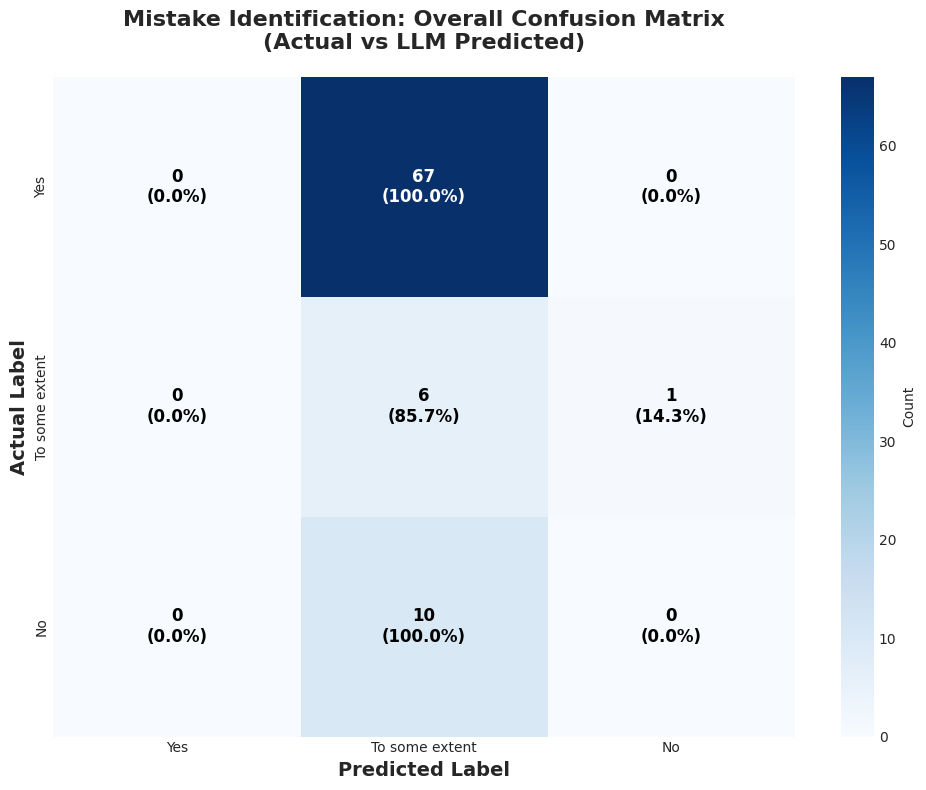


Overall Confusion Matrix:
[[ 0 67  0]
 [ 0  6  1]
 [ 0 10  0]]


In [44]:
def plot_confusion_matrix(y_true, y_pred, labels, title, save_path=None):
    """
    Plot a confusion matrix with percentages and counts.
    """
    # Calculate confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    
    # Calculate percentages
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    # Create figure
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Plot heatmap
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', 
                xticklabels=labels, yticklabels=labels,
                cbar_kws={'label': 'Count'}, ax=ax)
    
    # Add annotations with both count and percentage
    for i in range(len(labels)):
        for j in range(len(labels)):
            text = f'{cm[i, j]}\n({cm_percent[i, j]:.1f}%)'
            ax.text(j + 0.5, i + 0.5, text,
                   ha='center', va='center',
                   color='white' if cm[i, j] > cm.max() / 2 else 'black',
                   fontsize=12, fontweight='bold')
    
    ax.set_xlabel('Predicted Label', fontsize=14, fontweight='bold')
    ax.set_ylabel('Actual Label', fontsize=14, fontweight='bold')
    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved confusion matrix to: {save_path}")
    
    plt.show()
    
    return cm

# Define label order
label_order = ['Yes', 'To some extent', 'No']

# Overall confusion matrix
print("Generating overall confusion matrix...")
cm_overall = plot_confusion_matrix(
    analysis_df['actual'],
    analysis_df['predicted'],
    labels=label_order,
    title='Mistake Identification: Overall Confusion Matrix\n(Actual vs LLM Predicted)',
    save_path=os.path.join(OUTPUT_DIR, 'confusion_matrix_overall.png')
)

print(f"\nOverall Confusion Matrix:\n{cm_overall}")

## Step 12: Generate Confusion Matrices by Source

Create separate confusion matrices for each tutor response source (GPT4, Llama, Expert, etc.).

Creating confusion matrices for 9 sources...

Saved source-wise confusion matrices to: /DATA/cs24resch11011/repos/pedagogical-assessment/devendra/mistake_identification/llm_approach/confusion_matrices_by_source.png


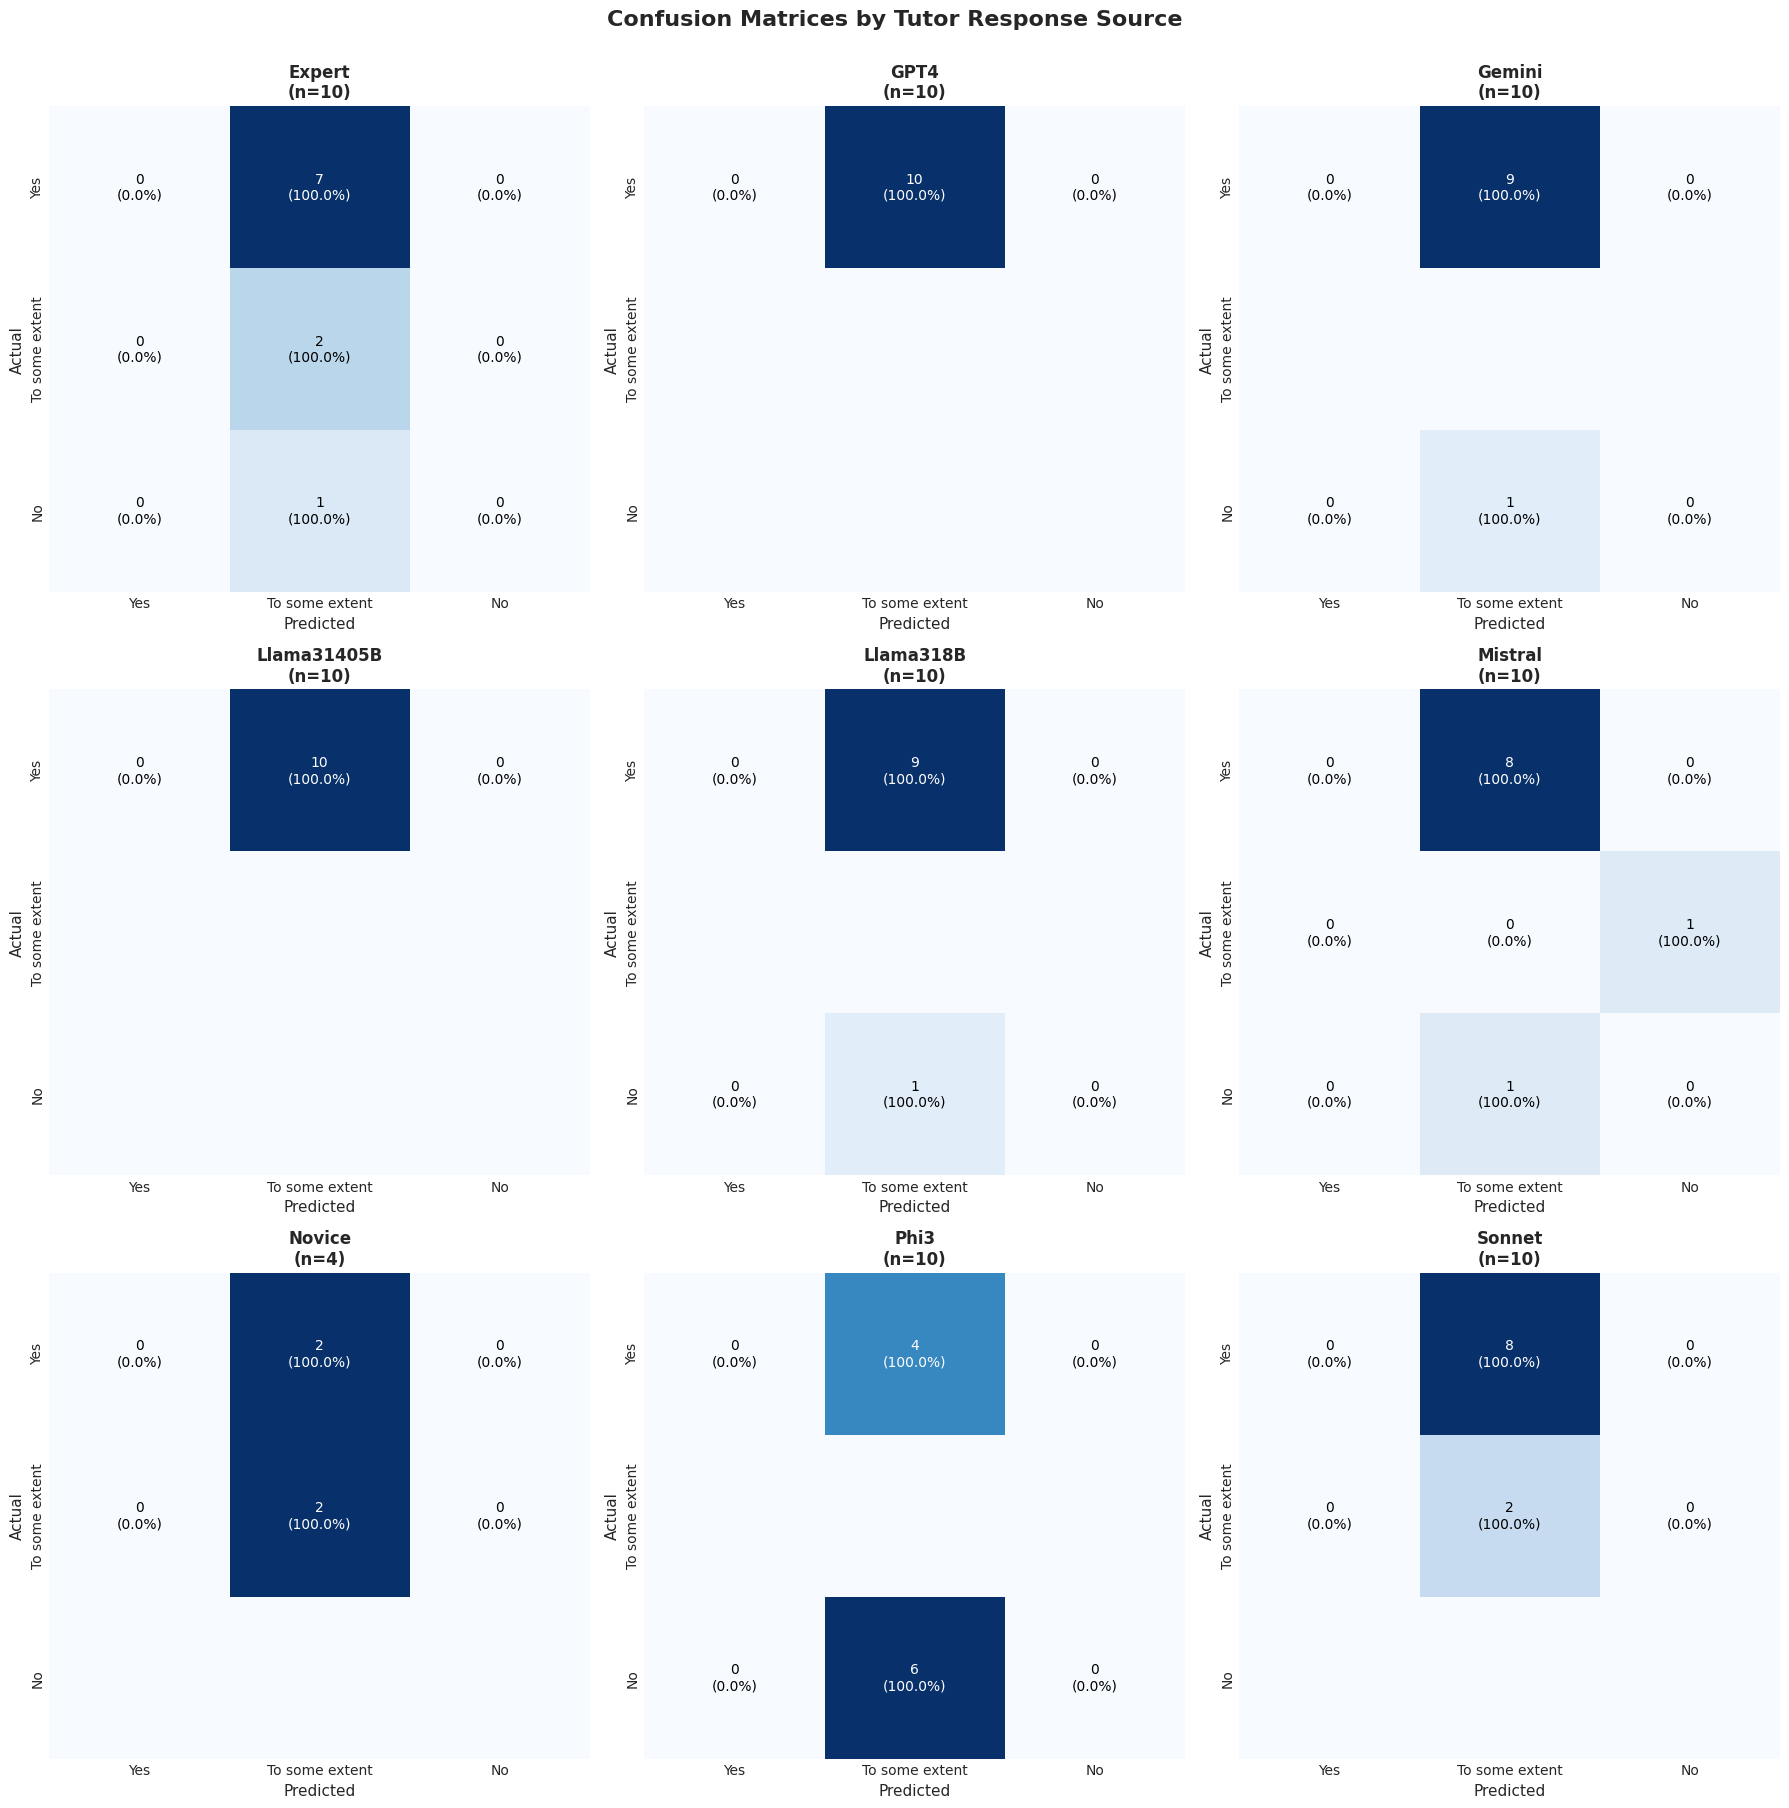

In [45]:
# Create confusion matrices for each source
sources = analysis_df['source'].unique()

print(f"Creating confusion matrices for {len(sources)} sources...\n")

# Create a grid of subplots
n_sources = len(sources)
n_cols = 3
n_rows = (n_sources + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6*n_rows))
axes = axes.flatten() if n_sources > 1 else [axes]

for idx, source in enumerate(sorted(sources)):
    source_df = analysis_df[analysis_df['source'] == source]
    
    # Calculate confusion matrix
    cm = confusion_matrix(source_df['actual'], source_df['predicted'], labels=label_order)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    # Plot
    ax = axes[idx]
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
                xticklabels=label_order, yticklabels=label_order,
                cbar=False, ax=ax)
    
    # Add annotations
    for i in range(len(label_order)):
        for j in range(len(label_order)):
            if not np.isnan(cm_percent[i, j]):
                text = f'{cm[i, j]}\n({cm_percent[i, j]:.1f}%)'
                ax.text(j + 0.5, i + 0.5, text,
                       ha='center', va='center',
                       color='white' if cm[i, j] > cm.max() / 2 else 'black',
                       fontsize=10)
    
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)
    ax.set_title(f'{source}\n(n={len(source_df)})', fontsize=12, fontweight='bold')

# Hide empty subplots
for idx in range(n_sources, len(axes)):
    axes[idx].axis('off')

plt.suptitle('Confusion Matrices by Tutor Response Source', 
             fontsize=16, fontweight='bold', y=1.002)
plt.tight_layout()

save_path = os.path.join(OUTPUT_DIR, 'confusion_matrices_by_source.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved source-wise confusion matrices to: {save_path}")
plt.show()

## Step 13: Calculate Performance Metrics

Calculate accuracy, F1 scores, and other metrics for the evaluation.

In [46]:
def calculate_metrics(y_true, y_pred, labels):
    """
    Calculate various performance metrics.
    """
    # Overall accuracy
    accuracy = accuracy_score(y_true, y_pred)
    
    # F1 scores
    f1_macro = f1_score(y_true, y_pred, labels=labels, average='macro', zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, labels=labels, average='weighted', zero_division=0)
    
    # Per-class F1 scores
    f1_per_class = f1_score(y_true, y_pred, labels=labels, average=None, zero_division=0)
    
    # Classification report
    report = classification_report(y_true, y_pred, labels=labels, zero_division=0)
    
    return {
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'f1_per_class': dict(zip(labels, f1_per_class)),
        'report': report
    }

# Calculate overall metrics
print("="*80)
print("OVERALL PERFORMANCE METRICS")
print("="*80)

overall_metrics = calculate_metrics(
    analysis_df['actual'],
    analysis_df['predicted'],
    label_order
)

print(f"\nAccuracy: {overall_metrics['accuracy']:.4f}")
print(f"F1 Score (Macro): {overall_metrics['f1_macro']:.4f}")
print(f"F1 Score (Weighted): {overall_metrics['f1_weighted']:.4f}")
print(f"\nF1 Scores per class:")
for label, score in overall_metrics['f1_per_class'].items():
    print(f"  {label}: {score:.4f}")

print(f"\n{'-'*80}")
print("DETAILED CLASSIFICATION REPORT")
print('-'*80)
print(overall_metrics['report'])

# Calculate metrics per source
print(f"\n{'='*80}")
print("PERFORMANCE METRICS BY SOURCE")
print("="*80)

source_metrics = []
for source in sorted(analysis_df['source'].unique()):
    source_df = analysis_df[analysis_df['source'] == source]
    
    metrics = calculate_metrics(
        source_df['actual'],
        source_df['predicted'],
        label_order
    )
    
    source_metrics.append({
        'Source': source,
        'Samples': len(source_df),
        'Accuracy': metrics['accuracy'],
        'F1_Macro': metrics['f1_macro'],
        'F1_Weighted': metrics['f1_weighted']
    })

metrics_df = pd.DataFrame(source_metrics)
metrics_df = metrics_df.sort_values('Accuracy', ascending=False)
print(f"\n{metrics_df.to_string(index=False)}")

# Save metrics
metrics_df.to_csv(os.path.join(OUTPUT_DIR, 'performance_metrics_by_source.csv'), index=False)
print(f"\nSaved metrics to: {os.path.join(OUTPUT_DIR, 'performance_metrics_by_source.csv')}")

OVERALL PERFORMANCE METRICS

Accuracy: 0.0714
F1 Score (Macro): 0.0444
F1 Score (Weighted): 0.0111

F1 Scores per class:
  Yes: 0.0000
  To some extent: 0.1333
  No: 0.0000

--------------------------------------------------------------------------------
DETAILED CLASSIFICATION REPORT
--------------------------------------------------------------------------------
                precision    recall  f1-score   support

           Yes       0.00      0.00      0.00        67
To some extent       0.07      0.86      0.13         7
            No       0.00      0.00      0.00        10

      accuracy                           0.07        84
     macro avg       0.02      0.29      0.04        84
  weighted avg       0.01      0.07      0.01        84


PERFORMANCE METRICS BY SOURCE

     Source  Samples  Accuracy  F1_Macro  F1_Weighted
     Novice        4       0.5  0.222222     0.333333
     Expert       10       0.2  0.111111     0.066667
     Sonnet       10       0.2  0.111111    

## Step 14: Visualize Performance Metrics

Create bar plots comparing performance across different sources.

Saved performance analysis to: /DATA/cs24resch11011/repos/pedagogical-assessment/devendra/mistake_identification/llm_approach/performance_analysis.png


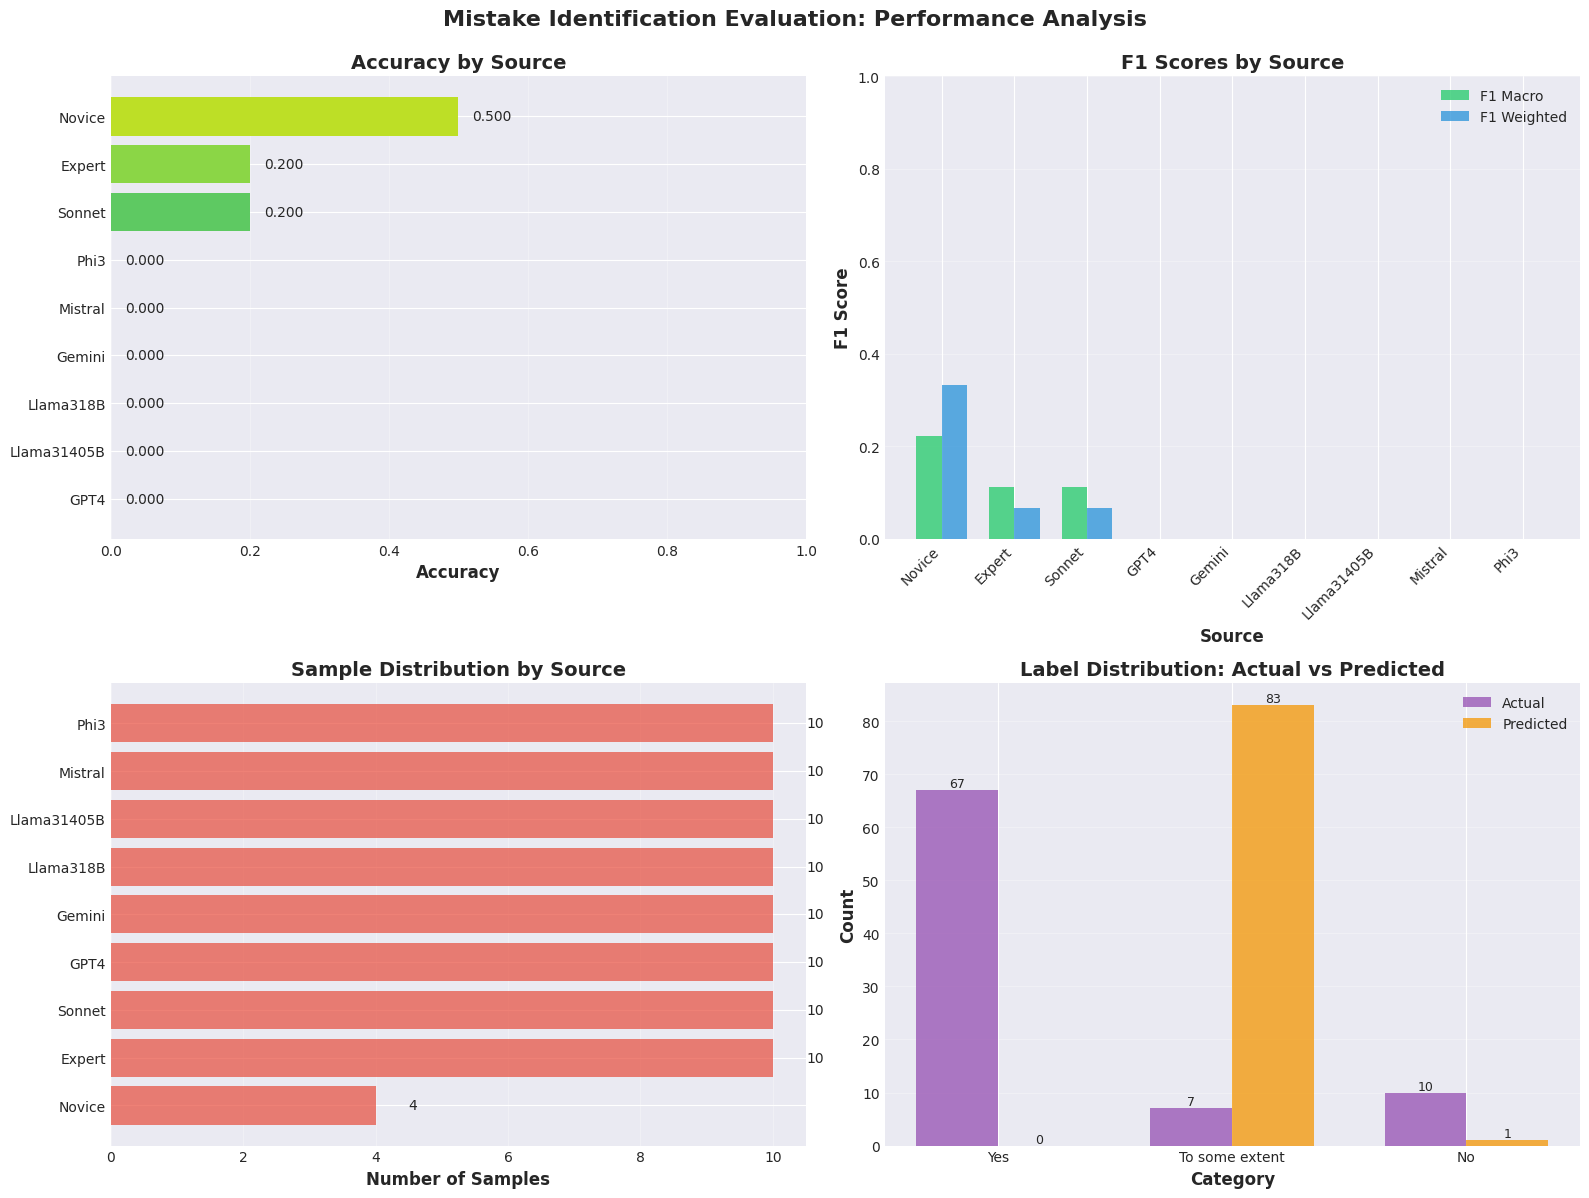

In [47]:
# Create comprehensive performance visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Accuracy by Source
ax1 = axes[0, 0]
metrics_df_sorted = metrics_df.sort_values('Accuracy', ascending=True)
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(metrics_df_sorted)))
bars1 = ax1.barh(metrics_df_sorted['Source'], metrics_df_sorted['Accuracy'], color=colors)
ax1.set_xlabel('Accuracy', fontsize=12, fontweight='bold')
ax1.set_title('Accuracy by Source', fontsize=14, fontweight='bold')
ax1.set_xlim(0, 1.0)
ax1.grid(axis='x', alpha=0.3)

# Add value labels
for i, bar in enumerate(bars1):
    width = bar.get_width()
    ax1.text(width + 0.02, bar.get_y() + bar.get_height()/2, 
             f'{width:.3f}',
             ha='left', va='center', fontsize=10)

# 2. F1 Scores Comparison
ax2 = axes[0, 1]
x = np.arange(len(metrics_df))
width = 0.35
bars2_1 = ax2.bar(x - width/2, metrics_df['F1_Macro'], width, 
                   label='F1 Macro', color='#2ecc71', alpha=0.8)
bars2_2 = ax2.bar(x + width/2, metrics_df['F1_Weighted'], width, 
                   label='F1 Weighted', color='#3498db', alpha=0.8)
ax2.set_xlabel('Source', fontsize=12, fontweight='bold')
ax2.set_ylabel('F1 Score', fontsize=12, fontweight='bold')
ax2.set_title('F1 Scores by Source', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(metrics_df['Source'], rotation=45, ha='right')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(0, 1.0)

# 3. Sample Distribution
ax3 = axes[1, 0]
sample_counts = metrics_df.sort_values('Samples', ascending=True)
bars3 = ax3.barh(sample_counts['Source'], sample_counts['Samples'], 
                 color='#e74c3c', alpha=0.7)
ax3.set_xlabel('Number of Samples', fontsize=12, fontweight='bold')
ax3.set_title('Sample Distribution by Source', fontsize=14, fontweight='bold')
ax3.grid(axis='x', alpha=0.3)

# Add value labels
for bar in bars3:
    width = bar.get_width()
    ax3.text(width + 0.5, bar.get_y() + bar.get_height()/2, 
             f'{int(width)}',
             ha='left', va='center', fontsize=10)

# 4. Label Distribution Comparison
ax4 = axes[1, 1]
label_dist_actual = analysis_df['actual'].value_counts()[label_order]
label_dist_pred = analysis_df['predicted'].value_counts().reindex(label_order, fill_value=0)

x = np.arange(len(label_order))
width = 0.35
bars4_1 = ax4.bar(x - width/2, label_dist_actual, width, 
                   label='Actual', color='#9b59b6', alpha=0.8)
bars4_2 = ax4.bar(x + width/2, label_dist_pred, width, 
                   label='Predicted', color='#f39c12', alpha=0.8)
ax4.set_xlabel('Category', fontsize=12, fontweight='bold')
ax4.set_ylabel('Count', fontsize=12, fontweight='bold')
ax4.set_title('Label Distribution: Actual vs Predicted', fontsize=14, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(label_order)
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars4_1, bars4_2]:
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2, height,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=9)

plt.suptitle('Mistake Identification Evaluation: Performance Analysis', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()

save_path = os.path.join(OUTPUT_DIR, 'performance_analysis.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved performance analysis to: {save_path}")
plt.show()

## Step 15: Agreement Analysis

Analyze agreement patterns between actual and predicted labels.

In [48]:
# Calculate agreement statistics
analysis_df['agreement'] = analysis_df['actual'] == analysis_df['predicted']

print("="*80)
print("AGREEMENT ANALYSIS")
print("="*80)

# Overall agreement
overall_agreement = analysis_df['agreement'].mean()
print(f"\nOverall Agreement Rate: {overall_agreement:.2%}")
print(f"Total Samples: {len(analysis_df)}")
print(f"Agreements: {analysis_df['agreement'].sum()}")
print(f"Disagreements: {(~analysis_df['agreement']).sum()}")

# Agreement by source
print(f"\n{'-'*80}")
print("Agreement by Source:")
print('-'*80)
agreement_by_source = analysis_df.groupby('source')['agreement'].agg(['mean', 'sum', 'count'])
agreement_by_source.columns = ['Agreement_Rate', 'Agreements', 'Total']
agreement_by_source = agreement_by_source.sort_values('Agreement_Rate', ascending=False)
agreement_by_source['Agreement_Rate'] = agreement_by_source['Agreement_Rate'].apply(lambda x: f"{x:.2%}")
print(agreement_by_source)

# Agreement by actual label
print(f"\n{'-'*80}")
print("Agreement by Actual Label:")
print('-'*80)
agreement_by_label = analysis_df.groupby('actual')['agreement'].agg(['mean', 'sum', 'count'])
agreement_by_label.columns = ['Agreement_Rate', 'Agreements', 'Total']
agreement_by_label = agreement_by_label.sort_values('Agreement_Rate', ascending=False)
agreement_by_label['Agreement_Rate'] = agreement_by_label['Agreement_Rate'].apply(lambda x: f"{x:.2%}")
print(agreement_by_label)

# Common misclassifications
print(f"\n{'-'*80}")
print("Most Common Misclassifications:")
print('-'*80)
misclassifications = analysis_df[~analysis_df['agreement']].groupby(['actual', 'predicted']).size().sort_values(ascending=False)
print(misclassifications.head(10))

AGREEMENT ANALYSIS

Overall Agreement Rate: 7.14%
Total Samples: 84
Agreements: 6
Disagreements: 78

--------------------------------------------------------------------------------
Agreement by Source:
--------------------------------------------------------------------------------
            Agreement_Rate  Agreements  Total
source                                       
Novice              50.00%           2      4
Expert              20.00%           2     10
Sonnet              20.00%           2     10
GPT4                 0.00%           0     10
Gemini               0.00%           0     10
Llama318B            0.00%           0     10
Llama31405B          0.00%           0     10
Mistral              0.00%           0     10
Phi3                 0.00%           0     10

--------------------------------------------------------------------------------
Agreement by Actual Label:
--------------------------------------------------------------------------------
               Agree

## Step 16: Error Analysis

Examine cases where predictions disagreed with actual labels.

In [49]:
# Show sample errors
print("="*80)
print("SAMPLE ERRORS (Predicted != Actual)")
print("="*80)

errors_df = analysis_df[~analysis_df['agreement']].copy()
print(f"\nTotal errors: {len(errors_df)}")

# Show a few examples of each type of error
error_types = errors_df.groupby(['actual', 'predicted']).size().sort_values(ascending=False)

for (actual, predicted), count in error_types.head(3).items():
    print(f"\n{'-'*80}")
    print(f"Error Type: Actual='{actual}' → Predicted='{predicted}' (Count: {count})")
    print('-'*80)
    
    sample = errors_df[(errors_df['actual'] == actual) & 
                       (errors_df['predicted'] == predicted)].iloc[0]
    
    print(f"Source: {sample['source']}")
    print(f"Conversation ID: {sample['conversation_id']}")
    print(f"\nTutor Response (first 300 chars):")
    print(sample['response'][:300] + "...")
    print()

# Save error analysis
errors_df.to_csv(os.path.join(OUTPUT_DIR, 'error_analysis.csv'), index=False)
print(f"\nSaved error analysis to: {os.path.join(OUTPUT_DIR, 'error_analysis.csv')}")

SAMPLE ERRORS (Predicted != Actual)

Total errors: 78

--------------------------------------------------------------------------------
Error Type: Actual='Yes' → Predicted='To some extent' (Count: 67)
--------------------------------------------------------------------------------
Source: Sonnet
Conversation ID: 221-362eb11a-f190-42a6-b2a4-985fafdcfa9e

Tutor Response (first 300 chars):
Great, you've correctly identified the cost of the meat, now let's focus on calculating the total cost of meat for all the sandwiches needed....


--------------------------------------------------------------------------------
Error Type: Actual='No' → Predicted='To some extent' (Count: 10)
--------------------------------------------------------------------------------
Source: Phi3
Conversation ID: 221-362eb11a-f190-42a6-b2a4-985fafdcfa9e

Tutor Response (first 300 chars):
To find the area of a rectangle, multiply its length by its width.

(Note: This instruction does not require a tutor response as 

## Step 17: Summary Report

Generate a comprehensive summary of the analysis.

In [50]:
# Generate summary report
summary_report = f"""
{'='*80}
MISTAKE IDENTIFICATION EVALUATION - SUMMARY REPORT
{'='*80}

1. DATASET INFORMATION
   - Total Conversations Processed: {len(trainset_evaluated)}
   - Total Evaluations: {len(analysis_df)}
   - Sources Evaluated: {', '.join(sorted(analysis_df['source'].unique()))}

2. OVERALL PERFORMANCE
   - Accuracy: {overall_metrics['accuracy']:.4f} ({overall_metrics['accuracy']*100:.2f}%)
   - F1 Score (Macro): {overall_metrics['f1_macro']:.4f}
   - F1 Score (Weighted): {overall_metrics['f1_weighted']:.4f}
   - Agreement Rate: {overall_agreement:.2%}

3. PER-CLASS PERFORMANCE (F1 Scores)
   - Yes: {overall_metrics['f1_per_class']['Yes']:.4f}
   - To some extent: {overall_metrics['f1_per_class']['To some extent']:.4f}
   - No: {overall_metrics['f1_per_class']['No']:.4f}

4. LABEL DISTRIBUTION
   Actual:
   - Yes: {label_dist_actual['Yes']}
   - To some extent: {label_dist_actual['To some extent']}
   - No: {label_dist_actual['No']}
   
   Predicted:
   - Yes: {label_dist_pred['Yes']}
   - To some extent: {label_dist_pred['To some extent']}
   - No: {label_dist_pred['No']}

5. TOP PERFORMING SOURCES (by Accuracy)
"""

for i, row in metrics_df.head(5).iterrows():
    summary_report += f"   {i+1}. {row['Source']}: {row['Accuracy']:.4f} ({row['Samples']} samples)\n"

summary_report += f"""
6. KEY INSIGHTS
   - Total Correct Predictions: {analysis_df['agreement'].sum()}
   - Total Incorrect Predictions: {(~analysis_df['agreement']).sum()}
   - Most Common Error: {error_types.index[0] if len(error_types) > 0 else 'N/A'}

7. OUTPUT FILES GENERATED
   - trainset_with_answers.json
   - trainset_with_answers_and_evaluations.json
   - confusion_matrix_overall.png
   - confusion_matrices_by_source.png
   - performance_analysis.png
   - performance_metrics_by_source.csv
   - error_analysis.csv
   - summary_report.txt

8. MODELS USED
   - Math Solver: Mistral Mathstral-7B-v0.1
   - Mistake Evaluator: Meta Llama-3.1-8B-Instruct

{'='*80}
ANALYSIS COMPLETE
{'='*80}
"""

print(summary_report)

# Save summary report
with open(os.path.join(OUTPUT_DIR, 'summary_report.txt'), 'w') as f:
    f.write(summary_report)

print(f"\nSummary report saved to: {os.path.join(OUTPUT_DIR, 'summary_report.txt')}")


MISTAKE IDENTIFICATION EVALUATION - SUMMARY REPORT

1. DATASET INFORMATION
   - Total Conversations Processed: 10
   - Total Evaluations: 84
   - Sources Evaluated: Expert, GPT4, Gemini, Llama31405B, Llama318B, Mistral, Novice, Phi3, Sonnet

2. OVERALL PERFORMANCE
   - Accuracy: 0.0714 (7.14%)
   - F1 Score (Macro): 0.0444
   - F1 Score (Weighted): 0.0111
   - Agreement Rate: 7.14%

3. PER-CLASS PERFORMANCE (F1 Scores)
   - Yes: 0.0000
   - To some extent: 0.1333
   - No: 0.0000

4. LABEL DISTRIBUTION
   Actual:
   - Yes: 67
   - To some extent: 7
   - No: 10

   Predicted:
   - Yes: 0
   - To some extent: 83
   - No: 1

5. TOP PERFORMING SOURCES (by Accuracy)
   7. Novice: 0.5000 (4 samples)
   1. Expert: 0.2000 (10 samples)
   9. Sonnet: 0.2000 (10 samples)
   2. GPT4: 0.0000 (10 samples)
   3. Gemini: 0.0000 (10 samples)

6. KEY INSIGHTS
   - Total Correct Predictions: 6
   - Total Incorrect Predictions: 78
   - Most Common Error: ('Yes', 'To some extent')

7. OUTPUT FILES GENERATE

## Additional Notes

### Processing Full Dataset

To process the entire trainset instead of just the sample, modify the `NUM_SAMPLES_TO_PROCESS` variable in Step 5:

```python
NUM_SAMPLES_TO_PROCESS = None  # Process all conversations
```

### Model Alternatives

If you don't have access to the specified models or want to use alternatives:

1. **Math Solver alternatives:**
   - `mistralai/Mistral-7B-Instruct-v0.2`
   - `WizardLM/WizardMath-7B-V1.1`
   - Any capable math-focused LLM

2. **Evaluator alternatives:**
   - `meta-llama/Llama-3.1-70B-Instruct` (if you have more GPU memory)
   - `meta-llama/Llama-2-7b-chat-hf`
   - API-based models (OpenAI GPT-4, Anthropic Claude, etc.)

### Requirements

Make sure you have the following packages installed:
```bash
pip install transformers torch accelerate tqdm pandas matplotlib seaborn scikit-learn
```

### GPU Requirements

- For Mathstral-7B: ~14GB GPU memory
- For Llama-3.1-8B: ~16GB GPU memory
- Both models together: ~30GB GPU memory (or use sequential loading)

If GPU memory is limited, you can:
1. Load one model at a time
2. Use quantized versions (8-bit or 4-bit)
3. Use CPU inference (slower but works)